# 1. ETL tabla 'mcc'

Partiendo de la conexión de Python con la página web de Kaggle a través de la librería 'kagglehub', hemos descargado el archivo 'mcc_codes.json' del conjunto de datos llamado 'Financial Transactions Dataset: Analytics'. Procederemos a limpiarlo, transformarlo, y le haremos un análisis exploratorio.

### Librerías importadas

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stat
from dotenv import load_dotenv

### Constantes

* Directorio actual del script de Python

In [2]:
# Consultar el directorio actual de trabajo y guardar en la constante 'CURRENT_DIRECTORY'
CURRENT_DIRECTORY=os.getcwd()
CURRENT_DIRECTORY

'C:\\Users\\yanig\\Python_Unicorn\\Proyecto_integrador'

* Directorio de la carpeta 'files'

In [3]:
# Crear una carpeta llamada 'files' dentro del directorio actual de trabajo
new_folder = 'files'

FILES_DIRECTORY=os.path.join(CURRENT_DIRECTORY, new_folder)

try:
    os.makedirs(FILES_DIRECTORY, exist_ok=True)
    print(f"Carpeta creada en: {FILES_DIRECTORY}")

except OSError as e:
    print(f"Error al crear la carpeta: {e}")

Carpeta creada en: C:\Users\yanig\Python_Unicorn\Proyecto_integrador\files


### Funciones creadas

In [4]:
# Categoriza las descripciones de los códigos
def categorize_mcc(desc):
    if pd.isna(desc):
        return 'Other / Misc'

    desc = desc.lower()

    mapping = {
        'Food & Beverage': ['restaurant', 'food', 'grocery', 'liquor', 'drink'],

        'Transportation': ['ship' 'taxi', 'transport', 'toll', 'bus', 'freight', 'railroad', 'stations', 'automotive','car washes', 'railways', 'towing services'],

        'Travel & Hospitality': ['airlines', 'hotel', 'travel', 'cruise', 'lodging'],

        'Retail & Shopping': ['store', 'clothing', 'shoe', 'electronics', 'furniture', 'gift', 'wholesale', 'antique', 'gardening supplies', 'leather goods'],

        'Utilities & Telecom': ['utilities', 'electric', 'gas', 'water', 'telecommunication', 'cable', 'computers'],

        'Healthcare': ['medical', 'doctor', 'hospital', 'pharmacy', 'dentist', 'chiropractors', 'optometrists', 'podiatrists'	],

        'Entertainment & Recreation': ['theater', 'casino', 'betting', 'sports', 'music', 'amusement', 'theatrical', 'books'],

        'Financial Services': ['money transfer', 'insurance'],

        'Professional Services': ['legal', 'accounting', 'tax', 'heating', 'detective agencies', 'postal services'],

        'Personal Services': ['cleaning', 'laundry', 'beauty', 'repair', 'florists'],

        'Industrial & Manufacturing': ['metals','ship' , 'metal', 'steel', 'manufacturing', 'machinery', 'building', 'industrial', 'semiconductors', 'polishing', 'ironwork', 'stone','coated', 'pottery'],

        'Digital & Subscriptions': ['digital', 'apps', 'games', 'network']
    }

    for category, keywords in mapping.items():
        if any(word in desc for word in keywords):
            return category

    return 'Other / Misc'

### Descarga del archivo de datos crudos

In [5]:
# Descargar el archivo de datos crudos 'mcc_codes.json' del dataset 'Financial Transactions Dataset: Analytics' de la página web de Kaggle
path = kagglehub.dataset_download('computingvictor/transactions-fraud-datasets', path='mcc_codes.json')
print('Archivo csv descargado en:', path)

Archivo csv descargado en: C:\Users\yanig\.cache\kagglehub\datasets\computingvictor\transactions-fraud-datasets\versions\1\mcc_codes.json


In [6]:
# Importar el documento
import json

with open(path, 'r') as f:
    data = json.load(f)

In [7]:
# Crear un dataframe del documento
df_mcc = pd.DataFrame(list(data.items()), columns=['mcc_code', 'name_mcc'])

In [8]:
# Chequear el dataframe importado
df_mcc

,mcc_code,name_mcc
0,5812,Eating Places and Restaurants
1,5541,Service Stations
2,7996,"Amusement Parks, Carnivals, Circuses"
3,5411,"Grocery Stores, Supermarkets"
4,4784,Tolls and Bridge Fees
...,...,...
104,7549,Towing Services
105,5941,Sporting Goods Stores
106,5722,Household Appliance Stores
107,3009,Fabricated Structural Metal Products


### Información general del dataframe

In [9]:
# Mostrar las primeras 5 filas del dataframe para visualizar su contenido
df_mcc.head()

,mcc_code,name_mcc
0,5812,Eating Places and Restaurants
1,5541,Service Stations
2,7996,"Amusement Parks, Carnivals, Circuses"
3,5411,"Grocery Stores, Supermarkets"
4,4784,Tolls and Bridge Fees


El dataframe contiene datos de los Merchant Category Code o Código de Categoría de Comerciante. Cada registro equivale a un código identificador del comercio en función de los tipos de bienes o servicios que ofrece. Contiene las siguientes columnas:
* **mcc_code**: Merchant Category Code o Código de Categoría de Comerciante: Es el código identificador de cada comercio en función de los tipos de bienes o servicios que ofrecen.
* **name_mcc**: Es el nombre de cada comercio en función de los tipos de bienes o servicios que ofrecen.

In [10]:
# Revisar la información general de dataset
df_mcc.info()

<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   mcc_code  109 non-null    str  
 1   name_mcc  109 non-null    str  
dtypes: str(2)
memory usage: 1.8 KB


Observamos que:
* El dataframe contiene 109 registros, y 2 columnas.
* No existen datos nulos.
* Columnas con tipo de dato 'str': 'mcc_code', 'name_mcc'.

### Limpieza y transformación de datos

#### mcc_code

In [11]:
# Convertir a integer la columna 'mcc_code'
df_mcc['mcc_code'] = df_mcc['mcc_code'].astype(int)

In [12]:
# Chequear el tipo de dato modificado
df_mcc['mcc_code'].dtypes

dtype('int64')

#### name_mcc

In [13]:
# Imprimir todo el directorio de los códigos para entender las descripciones de los códigos y poder agrupar
for code, desc in zip(df_mcc['mcc_code'],df_mcc['name_mcc']):
    print(code, desc)

5812 Eating Places and Restaurants
5541 Service Stations
7996 Amusement Parks, Carnivals, Circuses
5411 Grocery Stores, Supermarkets
4784 Tolls and Bridge Fees
4900 Utilities - Electric, Gas, Water, Sanitary
5942 Book Stores
5814 Fast Food Restaurants
4829 Money Transfer
5311 Department Stores
5211 Lumber and Building Materials
5310 Discount Stores
3780 Computer Network Services
5499 Miscellaneous Food Stores
4121 Taxicabs and Limousines
5300 Wholesale Clubs
5719 Miscellaneous Home Furnishing Stores
7832 Motion Picture Theaters
5813 Drinking Places (Alcoholic Beverages)
4814 Telecommunication Services
5661 Shoe Stores
5977 Cosmetic Stores
8099 Medical Services
7538 Automotive Service Shops
5912 Drug Stores and Pharmacies
4111 Local and Suburban Commuter Transportation
5815 Digital Goods - Media, Books, Apps
8021 Dentists and Orthodontists
5921 Package Stores, Beer, Wine, Liquor
5655 Sports Apparel, Riding Apparel Stores
7230 Beauty and Barber Shops
3390 Miscellaneous Metalwork
7922 The

In [14]:
# Crear una nueva columna para categorizar automáticamente los códigos en categorías
df_mcc['mcc_category'] =df_mcc['name_mcc'].apply(categorize_mcc)
df_mcc

,mcc_code,name_mcc,mcc_category
0,5812,Eating Places and Restaurants,Food & Beverage
1,5541,Service Stations,Transportation
2,7996,"Amusement Parks, Carnivals, Circuses",Entertainment & Recreation
3,5411,"Grocery Stores, Supermarkets",Food & Beverage
4,4784,Tolls and Bridge Fees,Transportation
...,...,...,...
104,7549,Towing Services,Transportation
105,5941,Sporting Goods Stores,Retail & Shopping
106,5722,Household Appliance Stores,Retail & Shopping
107,3009,Fabricated Structural Metal Products,Industrial & Manufacturing


In [15]:
# Convertir todo el texto de la columna 'name_mcc' a minúscula
df_mcc['name_mcc'] = df_mcc['name_mcc'].str.lower()
df_mcc

,mcc_code,name_mcc,mcc_category
0,5812,eating places and restaurants,Food & Beverage
1,5541,service stations,Transportation
2,7996,"amusement parks, carnivals, circuses",Entertainment & Recreation
3,5411,"grocery stores, supermarkets",Food & Beverage
4,4784,tolls and bridge fees,Transportation
...,...,...,...
104,7549,towing services,Transportation
105,5941,sporting goods stores,Retail & Shopping
106,5722,household appliance stores,Retail & Shopping
107,3009,fabricated structural metal products,Industrial & Manufacturing


In [16]:
# Convertir todo el texto de la columna 'mcc_category' a minúscula
df_mcc['mcc_category'] = df_mcc[ 'mcc_category'].str.lower()
df_mcc

,mcc_code,name_mcc,mcc_category
0,5812,eating places and restaurants,food & beverage
1,5541,service stations,transportation
2,7996,"amusement parks, carnivals, circuses",entertainment & recreation
3,5411,"grocery stores, supermarkets",food & beverage
4,4784,tolls and bridge fees,transportation
...,...,...,...
104,7549,towing services,transportation
105,5941,sporting goods stores,retail & shopping
106,5722,household appliance stores,retail & shopping
107,3009,fabricated structural metal products,industrial & manufacturing


In [17]:
# Crear una nueva tabla llamada 'mcc_category' a partir del dataframe 'df_mcc' para separar en el modelo de datos las categorías de los códigos
mcc_category= df_mcc[['mcc_category']].drop_duplicates().reset_index(drop=True)
mcc_category

,mcc_category
0,food & beverage
1,transportation
2,entertainment & recreation
3,utilities & telecom
4,retail & shopping
5,financial services
6,industrial & manufacturing
7,digital & subscriptions
8,professional services
9,healthcare


In [18]:
# Ordenar de forma ascendente la columna 'mcc_category'
mcc_category.sort_values('mcc_category', inplace=True)
mcc_category

,mcc_category
7,digital & subscriptions
2,entertainment & recreation
5,financial services
0,food & beverage
9,healthcare
6,industrial & manufacturing
10,personal services
8,professional services
4,retail & shopping
1,transportation


In [19]:
# Crear una columna de id de categoría llamada 'id_mcc_category'
mcc_category.insert(0, 'id_mcc_category', range(1, len(mcc_category) + 1))
mcc_category

,id_mcc_category,mcc_category
7,1,digital & subscriptions
2,2,entertainment & recreation
5,3,financial services
0,4,food & beverage
9,5,healthcare
6,6,industrial & manufacturing
10,7,personal services
8,8,professional services
4,9,retail & shopping
1,10,transportation


In [20]:
# Resetear el índice para que el mismo empiece en 0
mcc_category.reset_index(drop=True, inplace=True)
mcc_category

,id_mcc_category,mcc_category
0,1,digital & subscriptions
1,2,entertainment & recreation
2,3,financial services
3,4,food & beverage
4,5,healthcare
5,6,industrial & manufacturing
6,7,personal services
7,8,professional services
8,9,retail & shopping
9,10,transportation


In [21]:
# Crear una tabla llamada 'mcc' a partir del dataframe 'df_mcc' y relacionarla con la tabla 'mcc_category' para que contenga los códigos,  
# los nombres de los códigos, y el id de la categoría a la que pertenece cada código
mcc= df_mcc.merge(mcc_category, on='mcc_category', how='left')
mcc.head()

,mcc_code,name_mcc,mcc_category,id_mcc_category
0,5812,eating places and restaurants,food & beverage,4
1,5541,service stations,transportation,10
2,7996,"amusement parks, carnivals, circuses",entertainment & recreation,2
3,5411,"grocery stores, supermarkets",food & beverage,4
4,4784,tolls and bridge fees,transportation,10


In [22]:
# Eliminar la columna 'mcc_category'
mcc.drop(columns=['mcc_category'], inplace=True)
mcc

,mcc_code,name_mcc,id_mcc_category
0,5812,eating places and restaurants,4
1,5541,service stations,10
2,7996,"amusement parks, carnivals, circuses",2
3,5411,"grocery stores, supermarkets",4
4,4784,tolls and bridge fees,10
...,...,...,...
104,7549,towing services,10
105,5941,sporting goods stores,9
106,5722,household appliance stores,9
107,3009,fabricated structural metal products,6


In [23]:
# Renombrar la columna 'id_mcc_category' para que la nomenclatura del id esté alineada a las foreign key
mcc= mcc.rename(columns={'id_mcc_category': 'mcc_category_id'})
mcc

,mcc_code,name_mcc,mcc_category_id
0,5812,eating places and restaurants,4
1,5541,service stations,10
2,7996,"amusement parks, carnivals, circuses",2
3,5411,"grocery stores, supermarkets",4
4,4784,tolls and bridge fees,10
...,...,...,...
104,7549,towing services,10
105,5941,sporting goods stores,9
106,5722,household appliance stores,9
107,3009,fabricated structural metal products,6


In [24]:
# Ordenar de forma ascendente la columna 'mcc_code'
mcc.sort_values('mcc_code', inplace=True)
mcc

,mcc_code,name_mcc,mcc_category_id
93,1711,"heating, plumbing, air conditioning contractors",8
101,3000,steelworks,6
74,3001,steel products manufacturing,6
99,3005,miscellaneous metal fabrication,6
91,3006,miscellaneous fabricated metal products,6
...,...,...,...
86,8062,hospitals,5
22,8099,medical services,5
63,8111,legal services and attorneys,8
85,8931,"accounting, auditing, and bookkeeping services",8


In [25]:
# Resetear el índice para que el mismo empiece en 0
mcc.reset_index(drop=True, inplace=True)
mcc

,mcc_code,name_mcc,mcc_category_id
0,1711,"heating, plumbing, air conditioning contractors",8
1,3000,steelworks,6
2,3001,steel products manufacturing,6
3,3005,miscellaneous metal fabrication,6
4,3006,miscellaneous fabricated metal products,6
...,...,...,...
104,8062,hospitals,5
105,8099,medical services,5
106,8111,legal services and attorneys,8
107,8931,"accounting, auditing, and bookkeeping services",8


## Análisis Exploratorio de Datos (EDA)

In [26]:
# Exploramos la información general de los dataframes a analizar
dataframe_list = [mcc, mcc_category]
dataframe_name = ['mcc', 'mcc_category']

for i, df in enumerate(dataframe_list):
    print('\n', f'dataframe: ** {dataframe_name[i]} **')
    print(df.info(show_counts=True), '\n')


 dataframe: ** mcc **
<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   mcc_code         109 non-null    int64
 1   name_mcc         109 non-null    str  
 2   mcc_category_id  109 non-null    int64
dtypes: int64(2), str(1)
memory usage: 2.7 KB
None 


 dataframe: ** mcc_category **
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id_mcc_category  12 non-null     int64
 1   mcc_category     12 non-null     str  
dtypes: int64(1), str(1)
memory usage: 324.0 bytes
None 



In [27]:
# Unimos los dataframes 'mcc' y 'mcc_category' para poder analizarlos
mcc_merged = pd.merge(mcc, mcc_category, left_on='mcc_category_id', right_on='id_mcc_category', how='left')
mcc_merged.sample(5)

,mcc_code,name_mcc,mcc_category_id,id_mcc_category,mcc_category
54,5310,discount stores,9,9,retail & shopping
61,5651,family clothing stores,9,9,retail & shopping
56,5411,"grocery stores, supermarkets",4,4,food & beverage
55,5311,department stores,9,9,retail & shopping
31,3775,railroad freight,10,10,transportation


In [28]:
# A efectos de dejar listo el dataframe para proceder al análisis, eliminamos las columnas que no suman valor
mcc_merged.drop(['mcc_category_id', 'id_mcc_category'], axis=1, inplace=True)
mcc_merged.sample(5)

,mcc_code,name_mcc,mcc_category
83,7011,"lodging - hotels, motels, resorts",travel & hospitality
1,3000,steelworks,industrial & manufacturing
47,5094,precious stones and metals,industrial & manufacturing
91,7542,car washes,transportation
34,4112,passenger railways,transportation


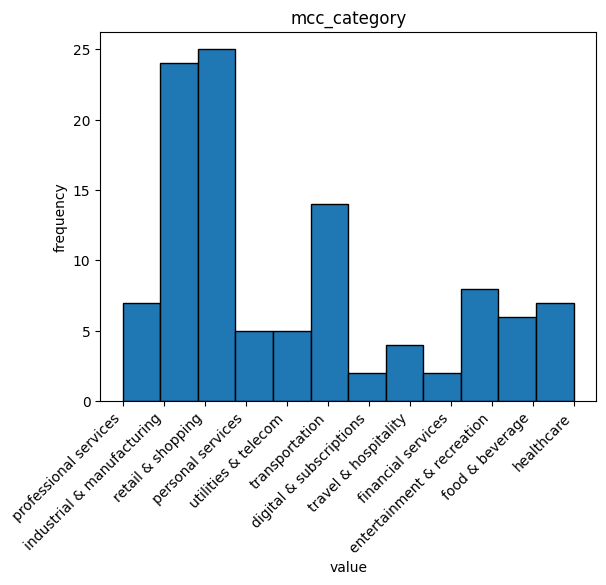

In [29]:
# Visualización
plt.hist(mcc_merged['mcc_category'], bins=12, edgecolor='black')
plt.title('mcc_category')
plt.xlabel('value')
plt.xticks(rotation=45, ha='right')
plt.ylabel('frequency')
plt.show()

* Conclusión:

Las categorías que tienen más códigos asociados son 'retail & shopping', seguido de 'industrial & manufacturing'. Las categorías que tienen menos códigos asociados son 'financial services' y 'digital & subscriptions'.

## Tablas limpias a conectar con MySQL Workbench y a exportar a formato .csv

* Exploramos la información general de los dataframes a conectar con MySQL Workbench y a exportar en formato .csv

In [30]:
dataframe_list = [mcc, mcc_category]
dataframe_name = ['mcc', 'mcc_category']

for i, df in enumerate(dataframe_list):
    print('\n', f'dataframe: ** {dataframe_name[i]} **')
    print(df.info(show_counts=True), '\n')


 dataframe: ** mcc **
<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   mcc_code         109 non-null    int64
 1   name_mcc         109 non-null    str  
 2   mcc_category_id  109 non-null    int64
dtypes: int64(2), str(1)
memory usage: 2.7 KB
None 


 dataframe: ** mcc_category **
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id_mcc_category  12 non-null     int64
 1   mcc_category     12 non-null     str  
dtypes: int64(1), str(1)
memory usage: 324.0 bytes
None 



* Cambiamos el directorio de trabajo a 'FILES_DIRECTORY' porque allí exportaremos las tablas 'limpias' en formato .csv

In [31]:
os.chdir(FILES_DIRECTORY)

* Chequeamos el directorio actual de trabajo

In [32]:
pwd!

'C:\\Users\\yanig\\Python_Unicorn\\Proyecto_integrador\\files'

* Exportamos de las tablas 'limpias' a formato .csv

In [33]:
mcc.to_csv('mcc.csv', index=False)
mcc_category.to_csv('mcc_category.csv', index=False)